In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm import camels, plotting, hpm, pm, nn

# jax.devices("gpu")

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

In [4]:
# parts_per_dim = None
# mesh_per_dim = 256
# mesh_shape = [mesh_per_dim] * 3

In [5]:
CV = "CV_0"
i_snapshots = range(1, 33+8, 8)
# i_snapshots = None

In [6]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# CAMELS

In [7]:
nbody_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

cosmo = nbody_dict["cosmo"]
scales = nbody_dict["scales"]

n_dm_poss = nbody_dict["dm_poss"]
n_dm_vels = nbody_dict["dm_vels"]
n_dm_masss = nbody_dict["dm_masss"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.86s/it]


In [8]:
hydro_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_cosmo = hydro_dict["cosmo"]
h_scales = hydro_dict["scales"]

h_dm_poss = hydro_dict["dm_poss"]
h_dm_vels = hydro_dict["dm_vels"]
h_gas_poss = hydro_dict["gas_poss"]
h_gas_vels = hydro_dict["gas_vels"]

h_dm_masss = hydro_dict["dm_masss"]
h_gas_masss = hydro_dict["gas_masss"]

# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 5/5 [01:12<00:00, 14.51s/it]


In [9]:
# plotting.compare_particle_evolution(
#     mesh_shape,
#     scales,
#     jnp.stack([n_dm_poss, h_dm_poss], axis=0),
#     include_pk=True,
#     include_reference=True,
#     # values
#     shared_colorbar=True,
#     # cosmetics
#     title=None,
#     col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(CAMELS, hydro)"],
# )

In [10]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# # nbody
# n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
# n_rho_dm = n_N_dm

# # hydro
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
# h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# h_rho_tot = h_rho_dm + h_rho_gas

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([n_N_dm, h_N_dm], axis=0),
#     title="CAMELS",
#     col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

In [11]:
# plotting.compare_particle_evolution(
#     mesh_shape,
#     scales,
#     jnp.stack([h_dm_poss, h_gas_poss], axis=0),
#     include_pk=True,
#     include_reference=True,
#     # values
#     shared_colorbar=True,
#     # cosmetics
#     title=None,
#     col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
# )

In [12]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# # hydro (uniform particle mass)
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
# h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([h_rho_dm, h_rho_gas], axis=0),
#     title="CAMELS",
#     col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

In [13]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# # hydro (varying particle mass)
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = hydro_dict["gas_masss"]

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = jax.vmap(cic_paint, in_axes=(None, 0, 0))(jnp.zeros(mesh_shape), h_gas_poss, h_gas_mass)

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([h_rho_dm, h_rho_gas], axis=0),
#     title="CAMELS",
#     col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

### constant mass

In [20]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# # nbody
# n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)

# n_dm_mass = 1.0
# n_rho_dm = n_dm_mass * n_N_dm

# # hydro
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
# h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# h_rho_tot = h_rho_dm + h_rho_gas

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([n_rho_dm, h_rho_tot], axis=0),
#     title="CAMELS",
#     col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

# print(jnp.sum(n_rho_dm))
# print(jnp.sum(h_rho_tot))

### mass from snapshot util

100%|██████████| 5/5 [00:01<00:00,  2.89it/s]


1310718.0
1313424.2


Text(0.5, 0.98, 'total matter')

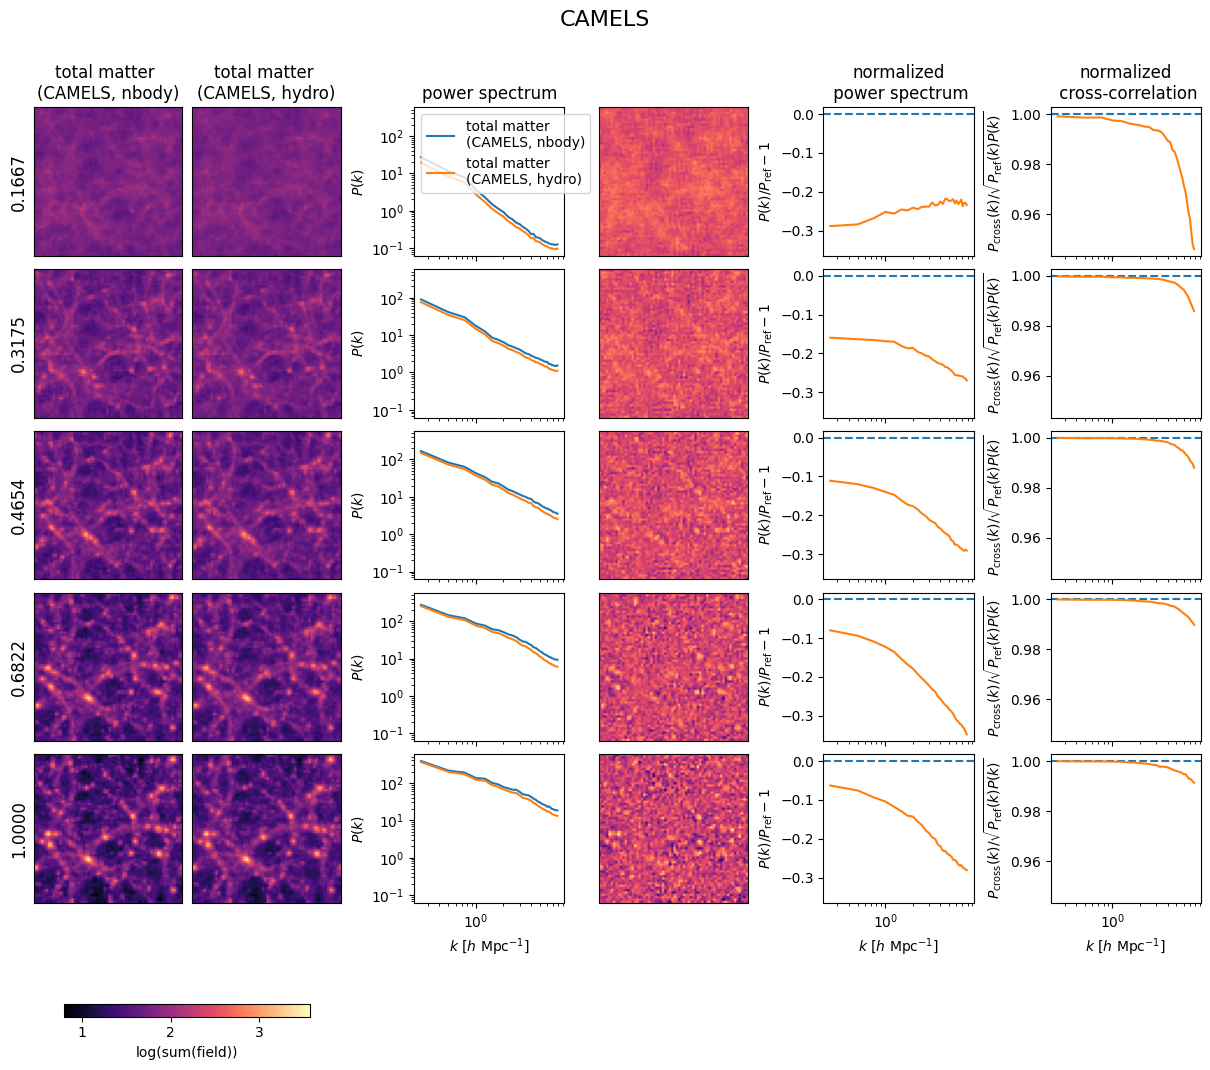

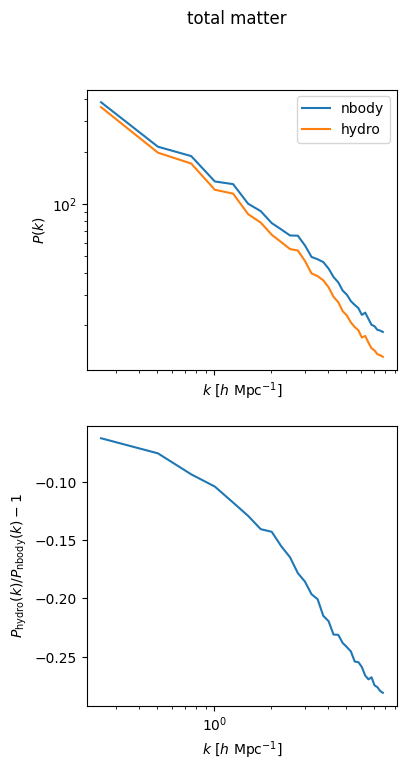

In [15]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0, 0))

# nbody
n_dm_masss = nbody_dict["dm_masss"]

n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss, n_dm_masss)

n_rho_tot = n_rho_dm

# hydro
h_dm_masss = hydro_dict["dm_masss"]
h_gas_masss = hydro_dict["gas_masss"]

h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss, h_dm_masss)
h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss, h_gas_masss)
h_rho_tot = h_rho_dm + h_rho_gas

plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_tot, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
    include_pk=True,
    include_reference=True,
)

print(jnp.sum(n_rho_dm))
print(jnp.sum(h_rho_tot))

box_size = 25.0

def pk_wrapper(field):
    k, pk = power_spectrum(
        compensate_cic(field),
        boxsize=np.array([box_size] * 3),
        kmin=np.pi / box_size,
        dk=2 * np.pi / box_size,
    )
    return k, pk

i = -1
k, n_pk_tot = pk_wrapper(n_rho_tot[i])
k, h_pk_tot = pk_wrapper(h_rho_tot[i])

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(4, 2*4))

ax[0].plot(k, n_pk_tot, label="nbody")
ax[0].plot(k, h_pk_tot, label="hydro")

ax[0].set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")
ax[0].legend()

ax[1].plot(k, h_pk_tot/n_pk_tot - 1, label="nbody")
ax[1].set(xscale="log", yscale="linear", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P_\text{hydro}(k)/P_\text{nbody}(k) - 1$")

fig.suptitle("total matter")

In [16]:
h_rho_tot[-1]

Array([[[6.78501576e-02, 3.33192348e-02, 0.00000000e+00, ...,
         6.79829195e-02, 3.73358577e-02, 2.78755762e-02],
        [3.02123129e-01, 1.36347413e-01, 8.78084153e-02, ...,
         1.88048333e-02, 5.15422709e-02, 3.60464692e-01],
        [3.53255033e-01, 1.42926738e-01, 5.22382967e-02, ...,
         6.11904442e-01, 1.04054451e-01, 3.09067160e-01],
        ...,
        [1.61818400e-01, 2.08394825e-02, 0.00000000e+00, ...,
         4.48944896e-01, 4.21618253e-01, 1.74837448e-02],
        [6.19805492e-02, 8.53647888e-02, 2.65681744e-02, ...,
         1.10585205e-01, 0.00000000e+00, 7.74358120e-03],
        [2.51700222e-01, 2.35440180e-01, 1.17434464e-01, ...,
         2.75296390e-01, 9.97357145e-02, 2.92680800e-01]],

       [[4.42111790e-01, 3.66193593e-01, 1.04224376e-01, ...,
         1.17403723e-01, 1.25840783e-01, 3.22607666e-01],
        [2.35338867e-01, 9.68365669e-02, 2.41124909e-03, ...,
         2.35285193e-01, 8.42448622e-02, 5.28894603e-01],
        [2.58818239e-01, 

In [17]:
h_rho_tot.shape

(5, 64, 64, 64)

100%|██████████| 5/5 [00:01<00:00,  2.86it/s]


1310718.0
1313424.2


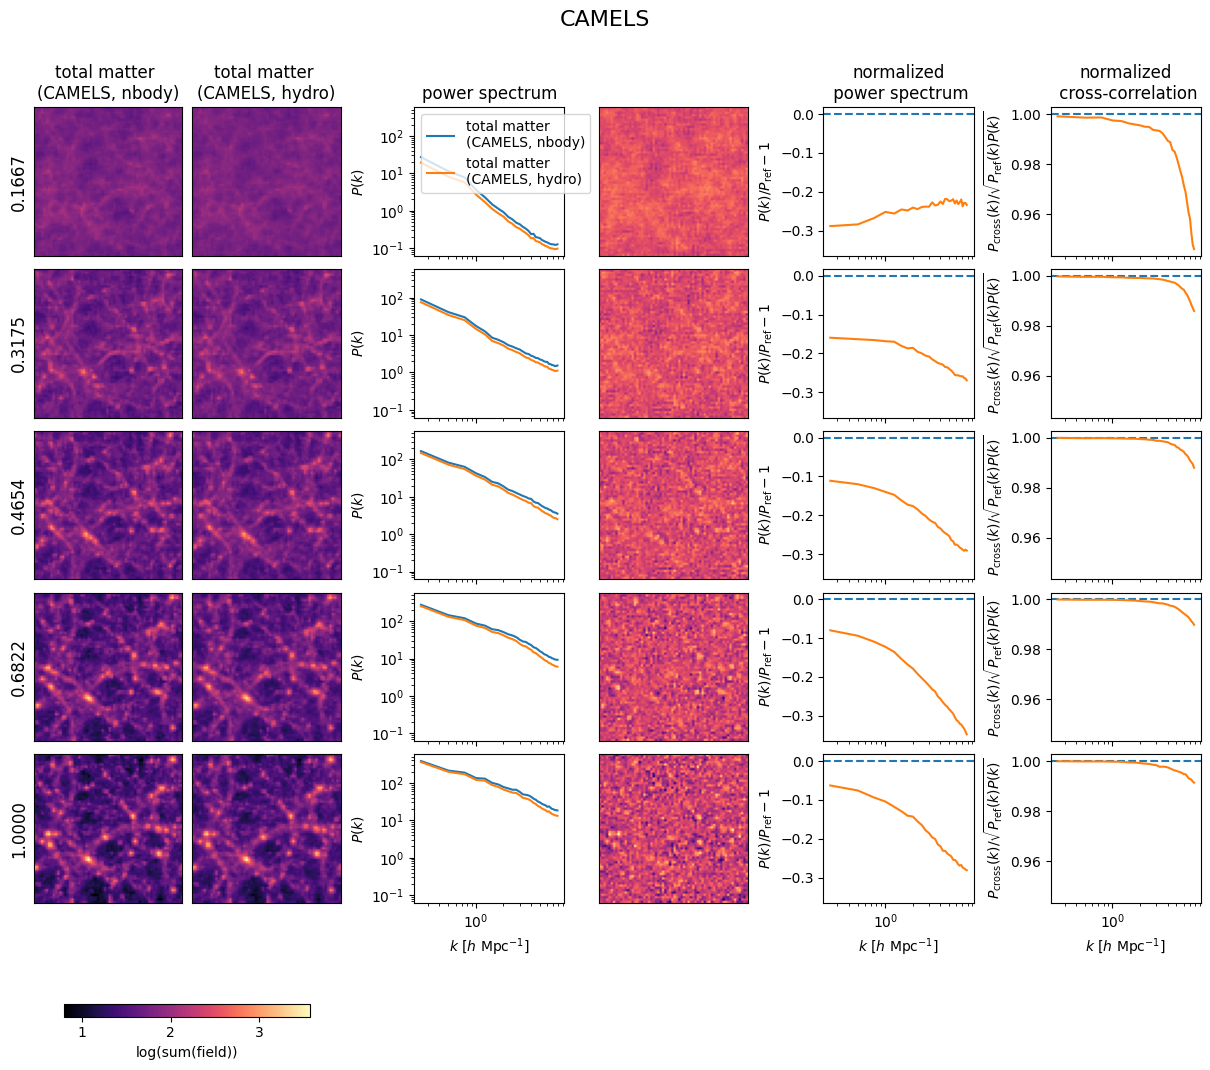

In [18]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# nbody
n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

# hydro
h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = hydro_dict["gas_masss"]

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)

h_rho_dm = h_dm_mass * h_N_dm
h_rho_gas = jax.vmap(cic_paint, in_axes=(None, 0, 0))(jnp.zeros(mesh_shape), h_gas_poss, h_gas_mass)

h_rho_tot = h_rho_dm + h_rho_gas

plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
    include_pk=True,
    include_reference=True,
)

print(jnp.sum(n_rho_dm))
print(jnp.sum(h_rho_tot))

# adding in cic paint vs. on the Cl level

In [19]:
stop

NameError: name 'stop' is not defined

### nbody

In [ ]:
n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

### hydro

In [ ]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = hydro_dict["gas_masss"]

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)

h_rho_dm = h_dm_mass * h_N_dm
h_rho_gas = jax.vmap(cic_paint, in_axes=(None, 0, 0))(jnp.zeros(mesh_shape), h_gas_poss, h_gas_mass)

h_rho_tot_0 = h_rho_dm + h_rho_gas

In [ ]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0, 0))

h_dm_mass = jnp.full(h_dm_poss.shape[:2], cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b))
h_gas_mass = hydro_dict["gas_masss"]
h_rho_tot_1 = vcic_paint(
    jnp.zeros(mesh_shape), 
    jnp.concatenate([h_dm_poss, h_gas_poss], axis=1),
    jnp.concatenate([h_dm_mass, h_gas_mass], axis=1)
)

In [ ]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([h_rho_tot_0, h_rho_tot_1], axis=0),
    col_titles=["total matter \n(CAMELS, hydro, 1)", "total matter \n(CAMELS, hydro, 1)"],
    include_pk=True,
    include_reference=True,
)

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([n_rho_dm, h_rho_tot_0, h_rho_tot_1], axis=0),
#     col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro, 1)", "total matter \n(CAMELS, hydro, 1)"],
#     include_pk=True,
#     include_reference=True,
# )

In [ ]:
from jaxpm.utils import cross_correlation_coefficients

box_size = 25.0 # comoving Mpc/h

def pk_wrapper(field):
    k, pk = power_spectrum(
        compensate_cic(field),
        boxsize=np.array([box_size] * 3),
        kmin=np.pi / box_size,
        dk=2 * np.pi / box_size,
    )
    return k, pk

def cross_wrapper(field_a, field_b):
    k, pk = cross_correlation_coefficients(
        compensate_cic(field_a),
        compensate_cic(field_b),
        boxsize=np.array([box_size] * 3),
        kmin=np.pi / box_size,
        dk=2 * np.pi / box_size,
    )
    return k, pk

vpk_wrapper = jax.vmap(pk_wrapper, in_axes=0)
vcross_wrapper = jax.vmap(cross_wrapper, in_axes=0)

f_c = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
f_b = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
h_pk_tot = f_c**2 * vpk_wrapper(h_N_dm)[1] + 2 * f_c * f_b * vcross_wrapper(h_N_dm, h_N_gas)[1] + f_b**2 * vpk_wrapper(h_N_gas)[1]

fig, ax = plt.subplots()

ax.plot(h_pk_tot.T)
ax.set(xscale="log", yscale="log")

In [ ]:
h_pk_tot_0 = vpk_wrapper(h_rho_tot_0)[1]

fig, ax = plt.subplots()

ax.plot(h_pk_tot.T)
ax.plot(h_pk_tot_0.T, linestyle=":")
ax.set(xscale="log", yscale="log")